In [1]:
import numpy as np
from scipy.fft import rfft, irfft

import matplotlib.pyplot as plt

In [2]:
def make_pink_noise(num_samples):
    #make white noise in time domain
    white_noise = np.random.randn(num_samples)

    #fft the white noise
    fft_white_noise = rfft(white_noise)

    #set freqs for rfft, ensure DC componenent nonzero
    frequencies = np.fft.rfftfreq(num_samples)
    frequencies[0] = 1e-10 
    
    #make any apply 1/f filter
    filter_magnitudes = 1 / np.sqrt(frequencies)
    fft_pink_noise = fft_white_noise * filter_magnitudes

    #now get pink noise in time domain
    pink_noise = irfft(fft_pink_noise, n=num_samples)

    #normalize to have STD of one
    pink_noise = pink_noise / np.std(pink_noise)
    pink_noise = pink_noise - np.mean(pink_noise)

    return pink_noise


def make_white_noise(num_samples):
    return np.random.randn(num_samples)

In [6]:
nsamps = 2**10
pink_td = make_pink_noise(nsamps)
white_td = make_white_noise(nsamps)

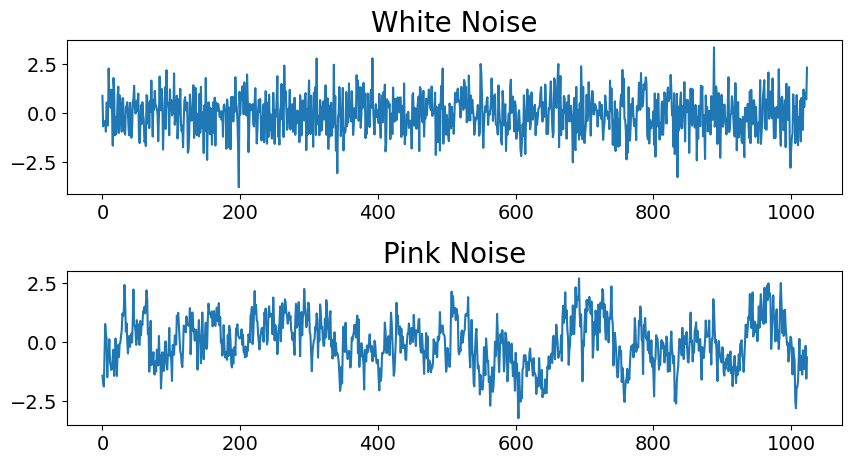

In [20]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 5))
plt.subplots_adjust(
    wspace=0.3,   
    hspace=0.5    
)

plt.rcParams.update({
            "font.size": 16,
            "axes.labelsize": 18,
            "axes.titlesize": 20,
            "xtick.labelsize": 14,
            "ytick.labelsize": 14,
            "figure.titlesize": 22
        })
ax[0].set_title("White Noise")
#ax[0].set_ylabel('Value (AU)')
ax[0].plot(white_td)


ax[1].set_title("Pink Noise")
#ax[1].set_xlabel('Sample Number')
#ax[1].set_ylabel('Value (AU)')
ax[1].plot(pink_td)
plt.tight_layout
plt.show()

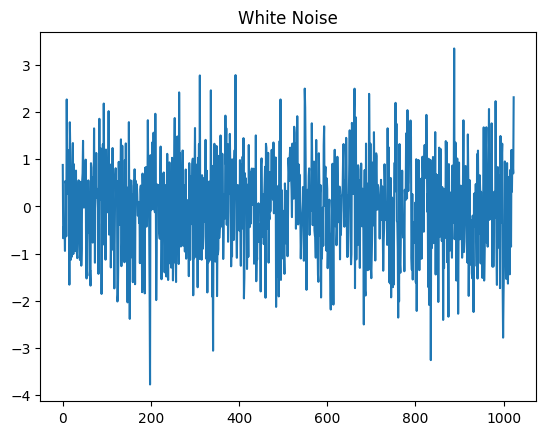

In [8]:
plt.plot(white_td)
plt.title("White Noise")
plt.show()